# 課題6 Vision Transformer

研究室共通データセット `/export/data/dataset/CIFAR` にある CIFAR-10 を使います。

In [1]:
from pathlib import Path
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

# ── パス設定 ──
BASE_DIR     = Path('/export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2')
TASK_DIR     = BASE_DIR / 'kadai6-vision_transformer'
OUT_DIR      = TASK_DIR / 'out'
MODEL_DIR    = TASK_DIR / 'model'
LAB_DATA_ROOT = Path('/export/data/dataset')

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── 学内プロキシ／IPv6 設定 ──
os.environ['http_proxy']           = 'http://proxy.uec.ac.jp:8080/'
os.environ['https_proxy']          = 'http://proxy.uec.ac.jp:8080/'
os.environ['HF_HUB_DISABLE_IPV6']  = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# ── 再現性 ──
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


device: cuda
GPU: NVIDIA TITAN RTX


In [2]:
def find_cifar_root():
    candidates = [
        LAB_DATA_ROOT / 'CIFAR',
        LAB_DATA_ROOT / 'CIFAR' / 'cifar-10-python',
        LAB_DATA_ROOT / 'CIFAR10',
    ]
    for root in candidates:
        if (root / 'cifar-10-batches-py').exists():
            return root
    raise FileNotFoundError(
        'CIFAR-10 が見つかりません。共通データセットパスを確認してください。'
    )

CIFAR_ROOT = find_cifar_root()
print('CIFAR root:', CIFAR_ROOT)

CIFAR root: /export/data/dataset/CIFAR


## データセットの準備

- **Train** / **Val** / **Test** の 3 分割を行います。
- Train のみ RandAugment で強い augmentation を適用。
- Val・Test は評価用なので Normalize のみ。

In [3]:
# ── ハイパーパラメータ（ここで一括管理）──
TRAIN_SIZE   = 2000   # 学習に使う枚数
VAL_SIZE     = 500    # validation 枚数
BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 3e-4
WEIGHT_DECAY = 0.05
GRAD_CLIP    = 1.0    # gradient clipping の max_norm
IMG_SIZE     = 224    # ViT-B/16 の入力サイズ

# ── Transform ──
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),   
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

# ── データセット読み込み ──
full_train = datasets.CIFAR10(root=CIFAR_ROOT, train=True,  download=False, transform=train_tf)
test_set   = datasets.CIFAR10(root=CIFAR_ROOT, train=False, download=False, transform=eval_tf)

all_indices   = list(range(len(full_train)))
rng           = np.random.default_rng(SEED)
shuffled      = rng.permutation(all_indices)
train_idx     = shuffled[:TRAIN_SIZE].tolist()
val_idx       = shuffled[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE].tolist()

# val は eval_tf を使うため別インスタンスから Subset を作る
full_train_eval = datasets.CIFAR10(root=CIFAR_ROOT, train=True, download=False, transform=eval_tf)

train_subset = Subset(full_train,       train_idx)
val_subset   = Subset(full_train_eval,  val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_set,     batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

CLASS_NAMES = full_train.classes
print(f'train: {len(train_subset)}, val: {len(val_subset)}, test: {len(test_set)}')
print('classes:', CLASS_NAMES)

train: 2000, val: 500, test: 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## モデル構築 — Partial Fine-tuning

全パラメータを学習すると過学習しやすく、計算コストも高い。
ここでは **head + 最終 2 ブロック** のみ `requires_grad=True` にし、
残りを凍結（freeze）します。

In [4]:
# ── ViT-B/16 ロード ──
weights = models.ViT_B_16_Weights.IMAGENET1K_V1
model   = models.vit_b_16(weights=weights)

for p in model.parameters():
    p.requires_grad = False

# 最終 2 ブロック（encoder.layers[10], [11]）と head を解凍
UNFREEZE_BLOCKS = 2
total_blocks = len(model.encoder.layers)          # ViT-B/16 = 12
for blk in model.encoder.layers[total_blocks - UNFREEZE_BLOCKS:]:
    for p in blk.parameters():
        p.requires_grad = True

# 分類 head を 10 クラス用に置き換え
model.heads.head = nn.Linear(model.heads.head.in_features, 10)
# head は新規作成なので自動的に requires_grad=True

model.to(device)

# 学習対象パラメータ数を確認
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')

# ── オプティマイザ & スケジューラ ──
opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

trainable params: 14,183,434 / 85,806,346  (16.5%)


In [5]:
def run_epoch(loader, training: bool):
    """1 epoch 分の forward/backward を実行し (loss, acc) を返す。"""
    model.train(training)
    total_loss = total_correct = total_n = 0

    ctx = torch.amp.autocast('cuda', enabled=(device.type == 'cuda'))
    with (torch.no_grad() if not training else torch.enable_grad()):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with ctx:
                logits = model(x)
                loss   = F.cross_entropy(logits, y)

            if training:
                opt.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    GRAD_CLIP
                )
                scaler.step(opt)
                scaler.update()

            total_loss    += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n       += x.size(0)

    return total_loss / total_n, total_correct / total_n


# ── 学習ループ ──
train_loss_log, train_acc_log = [], []
val_loss_log,   val_acc_log   = [], []
best_val_acc = 0.0

for ep in range(EPOCHS):
    t_loss, t_acc = run_epoch(tqdm(train_loader, desc=f'Train {ep+1}/{EPOCHS}'), training=True)
    v_loss, v_acc = run_epoch(val_loader, training=False)
    scheduler.step()

    train_loss_log.append(t_loss); train_acc_log.append(t_acc)
    val_loss_log.append(v_loss);   val_acc_log.append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), MODEL_DIR / 'vit_cifar10_best.pt')
        flag = '★ saved'
    else:
        flag = ''

    lr_now = scheduler.get_last_lr()[0]
    print(f'ep={ep+1:2d}  '
          f'train loss={t_loss:.4f} acc={t_acc:.4f}  '
          f'val loss={v_loss:.4f} acc={v_acc:.4f}  '
          f'lr={lr_now:.2e}  {flag}')

print(f'\nbest val acc: {best_val_acc:.4f}')

Train 1/10: 100%|██████████| 63/63 [00:03<00:00, 16.84it/s]


ep= 1  train loss=0.4942 acc=0.8505  val loss=0.1813 acc=0.9420  lr=2.93e-04  ★ saved


Train 2/10: 100%|██████████| 63/63 [00:03<00:00, 18.48it/s]


ep= 2  train loss=0.1425 acc=0.9510  val loss=0.1914 acc=0.9340  lr=2.71e-04  


Train 3/10: 100%|██████████| 63/63 [00:03<00:00, 18.69it/s]


...

ep= 8  train loss=0.0117 acc=0.9960  val loss=0.1428 acc=0.9580  lr=2.86e-05  ★ saved


Train 9/10: 100%|██████████| 63/63 [00:03<00:00, 18.57it/s]


ep= 9  train loss=0.0126 acc=0.9950  val loss=0.1477 acc=0.9540  lr=7.34e-06  


Train 10/10: 100%|██████████| 63/63 [00:03<00:00, 18.59it/s]


ep=10  train loss=0.0148 acc=0.9965  val loss=0.1469 acc=0.9540  lr=0.00e+00  

best val acc: 0.9580


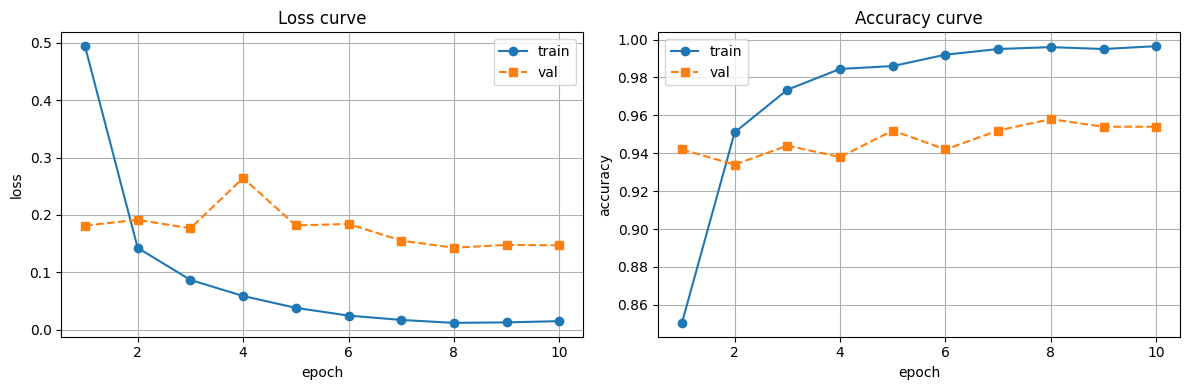

In [6]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_loss_log, 'o-', label='train')
axes[0].plot(epochs_range, val_loss_log,   's--', label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss curve'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, train_acc_log, 'o-', label='train')
axes[1].plot(epochs_range, val_acc_log,   's--', label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy curve'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / 'vit_loss_acc_curve.png', dpi=160, bbox_inches='tight')
plt.show()

In [7]:
# ── 最良モデルを読み込んでテスト評価 ──
model.load_state_dict(torch.load(MODEL_DIR / 'vit_cifar10_best.pt', map_location=device))
test_loss, test_acc = run_epoch(test_loader, training=False)
print(f'Test  loss={test_loss:.4f}  acc={test_acc:.4f}')

Test  loss=0.2456  acc=0.9409


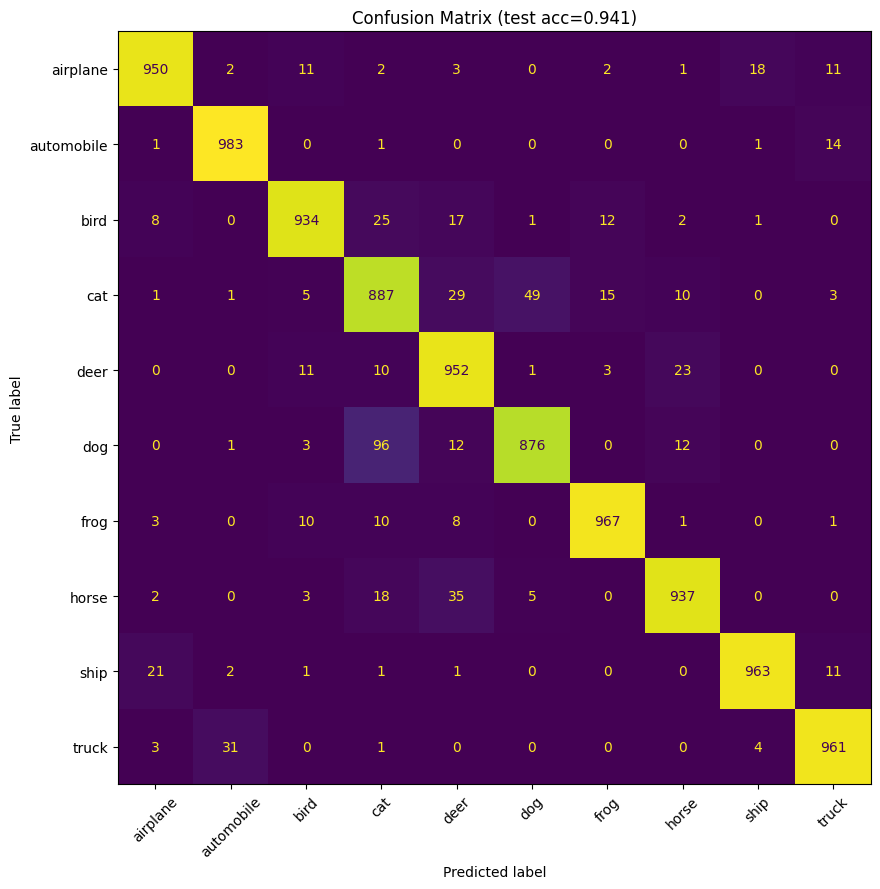

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f'Confusion Matrix (test acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig(OUT_DIR / 'vit_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

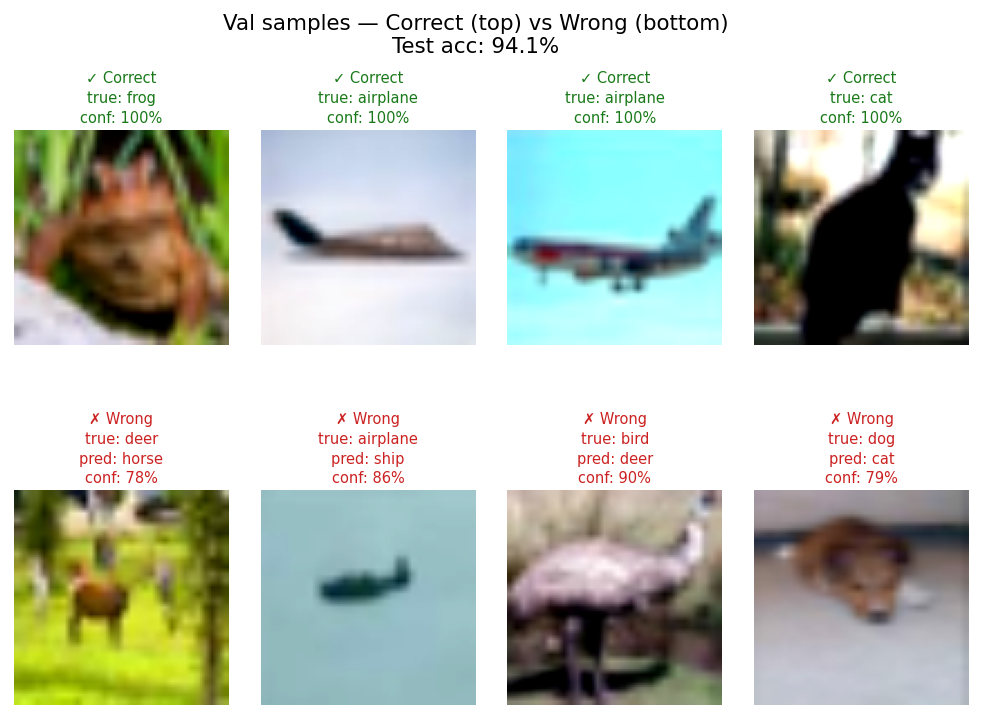

In [9]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def tensor_to_pil_sharp(img_tensor, sharpness=2.5, contrast=1.3):
    """Normalize 済み Tensor → シャープ化した PIL Image に変換。"""
    arr = (img_tensor.cpu() * std_t + mean_t).clamp(0, 1)
    pil = Image.fromarray((arr.permute(1, 2, 0).numpy() * 255).astype('uint8'))
    pil = ImageEnhance.Sharpness(pil).enhance(sharpness)   # シャープ化
    pil = ImageEnhance.Contrast(pil).enhance(contrast)     # コントラスト強調
    return pil

# ── val set からサンプル収集 ──
N_SAMPLES = 4   # 正解・誤答それぞれ何枚表示するか
correct_samples, wrong_samples = [], []
model.eval()

with torch.no_grad():
    for idx in range(len(val_subset)):
        img, label = val_subset[idx]
        logit = model(img.unsqueeze(0).to(device))
        prob  = torch.softmax(logit, dim=1)
        pred  = prob.argmax(1).item()
        conf  = prob.max().item()
        entry = (img, label, pred, conf)
        if pred == label and len(correct_samples) < N_SAMPLES:
            correct_samples.append(entry)
        elif pred != label and len(wrong_samples) < N_SAMPLES:
            wrong_samples.append(entry)
        if len(correct_samples) == N_SAMPLES and len(wrong_samples) == N_SAMPLES:
            break

# ── 描画 ──
THUMB = 96   # 表示サイズ（ピクセル） — 小さく・鮮明に
fig, axes = plt.subplots(
    2, N_SAMPLES,
    figsize=(N_SAMPLES * 2.2, 5.5),
    dpi=140,
    gridspec_kw={'hspace': 0.55, 'wspace': 0.15}
)

row_labels = ['✓ Correct', '✗ Wrong']
row_colors = ['#1a7a1a', '#cc2222']

for row, (samples, rlabel, rcolor) in enumerate(
    zip([correct_samples, wrong_samples], row_labels, row_colors)
):
    for col, (img, label, pred, conf) in enumerate(samples):
        ax = axes[row][col]
        pil = tensor_to_pil_sharp(img)
        pil_small = pil.resize((THUMB, THUMB), Image.LANCZOS)  # 高品質リサイズ
        ax.imshow(pil_small)
        ax.axis('off')

        # 枠線で正解・誤答を視覚的に区別
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(rcolor)
            spine.set_linewidth(2.5)

        title_lines = [rlabel]
        if pred == label:
            title_lines.append(f'true: {CLASS_NAMES[label]}')
            title_lines.append(f'conf: {conf:.0%}')
        else:
            title_lines.append(f'true: {CLASS_NAMES[label]}')
            title_lines.append(f'pred: {CLASS_NAMES[pred]}')
            title_lines.append(f'conf: {conf:.0%}')

        ax.set_title(
            '\n'.join(title_lines),
            color=rcolor, fontsize=7.5,
            pad=4, linespacing=1.4
        )

fig.suptitle(
    f'Val samples — Correct (top) vs Wrong (bottom)\n'
    f'Test acc: {test_acc:.1%}',
    fontsize=11, y=1.02
)
plt.savefig(
    OUT_DIR / 'vit_sample_predictions.png',
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()
